In [1]:
import ast
import matplotlib.pyplot as plt
import pandas as pd 
from datasets import load_dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)
df_DA=df[df['job_title_short']=='Data Analyst'].copy()

In [ ]:
df_DA['job_posted_month_no']=df_DA['job_posted_date'].dt.month


In [5]:
df_DA.head(2)


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month_no
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr...",1
12,Data Analyst,Stagiaire Data Analyst (H/F) - Lyon (69006),"Lyon, France",via Jobijoba,Full-time and Internship,False,France,2023-12-22 13:24:41,False,False,France,None,NaN,NaN,Engie,"[sql, php, excel, power bi, sap, jira]","{'analyst_tools': ['excel', 'power bi', 'sap']...",12


In [6]:
#Explode the job_skills column and pivot
df_DA_explode=df_DA.explode('job_skills')
df_DA_pivot=df_DA_explode.pivot_table(index='job_posted_month_no',columns='job_skills',aggfunc='size',fill_value=0)

In [7]:
#sort the skills by count
df_DA_pivot.loc['Total']=df_DA_pivot.sum()
df_DA_pivot=df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot=df_DA_pivot.drop('Total')

In [8]:
#Use month names for plotting
df_DA_pivot.index=df_DA_pivot.index.map({1:'January',2:'February',3:'March',4:'April',5:'May',6:'June',7:'July',8:'August',9:'September',10:'October',11:'November',12:'December'})
df_DA_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,word,sap,...,xamarin,mattermost,gtx,esquisse,chainer,capacitor,nuxt.js,msaccess,ovh,suse
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
January,11336,8170,6606,5596,4285,3607,3830,1880,1778,1251,...,0,0,0,0,0,1,1,0,0,0
February,7947,5772,4751,3936,3307,2576,2634,1291,1235,954,...,0,0,0,0,0,0,0,0,0,0
March,7868,5675,4741,4051,3176,2650,2554,1266,1203,892,...,1,0,0,0,0,0,0,0,0,1
April,7553,5496,4557,3776,3106,2399,2598,1190,1177,947,...,0,0,0,0,0,0,0,0,1,0
May,6617,4773,4070,3245,2695,2093,1940,979,957,851,...,0,0,0,0,0,0,0,1,0,0
June,7584,5724,4707,3812,3275,2442,2174,1173,1237,987,...,0,0,0,0,0,0,0,0,0,0
July,7687,5513,4831,3928,3350,2444,2118,1096,1069,996,...,0,0,1,0,0,0,0,0,0,0
August,8823,6482,5576,4533,3859,2975,2560,1332,1298,1117,...,0,0,0,0,0,0,0,0,0,0
September,6829,4886,4229,3446,3118,2146,1880,944,945,852,...,0,1,0,0,0,0,0,0,0,0


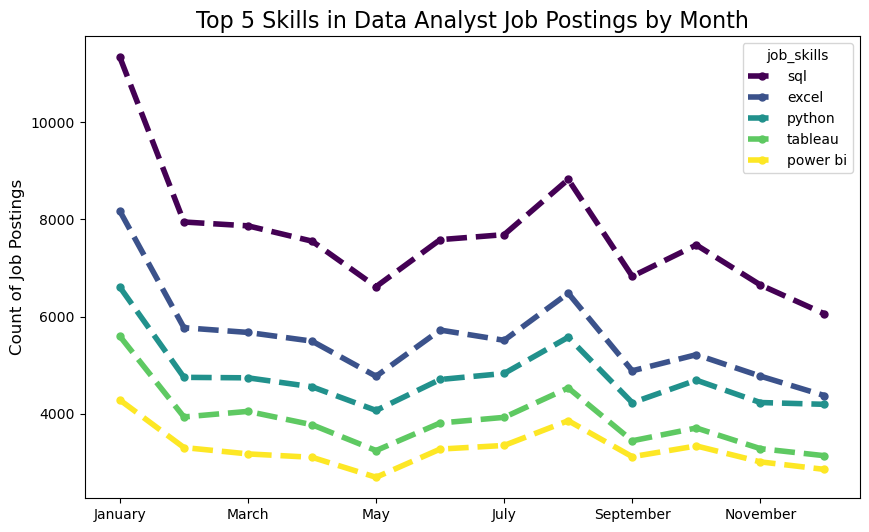

In [14]:
#get the top 5 skills
df_DA_pivot.iloc[:,:5].plot(
    kind='line',
    linewidth=4,
    linestyle='--',
    colormap='viridis',
    markersize=5,
    marker='o',
    figsize=(10,6)
)
plt.title('Top 5 Skills in Data Analyst Job Postings by Month', fontsize=16)
plt.xlabel('')
plt.ylabel('Count of Job Postings', fontsize=12)
plt.show()


In [15]:
#Explode the job_skillls into individual rows and group by skill to get count and median salary
df_exploded=df.explode('job_skills')
skill_stats=df_exploded.groupby('job_skills').agg(skill_count=('job_skills','count'),median_salary=('salary_year_avg', 'median'))

#Limit to top skills
skill_count=20
skill_stats=skill_stats.sort_values(by='skill_count',ascending=False).head(skill_count)
skill_stats

,skill_count,median_salary
job_skills,,
sql,384849,120000.0
python,380909,125000.0
aws,145381,135000.0
azure,132527,125000.0
r,130892,119550.0
tableau,127213,111175.0
excel,127018,92500.0
spark,114609,140000.0
power bi,98147,102000.0


In [16]:
from adjustText import adjust_text

C:\Users\sandr\AppData\Local\Temp\ipykernel_16660\3627135125.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts.append(plt.text(skill_stats['skill_count'][i], skill_stats['median_salary'][i], txt))


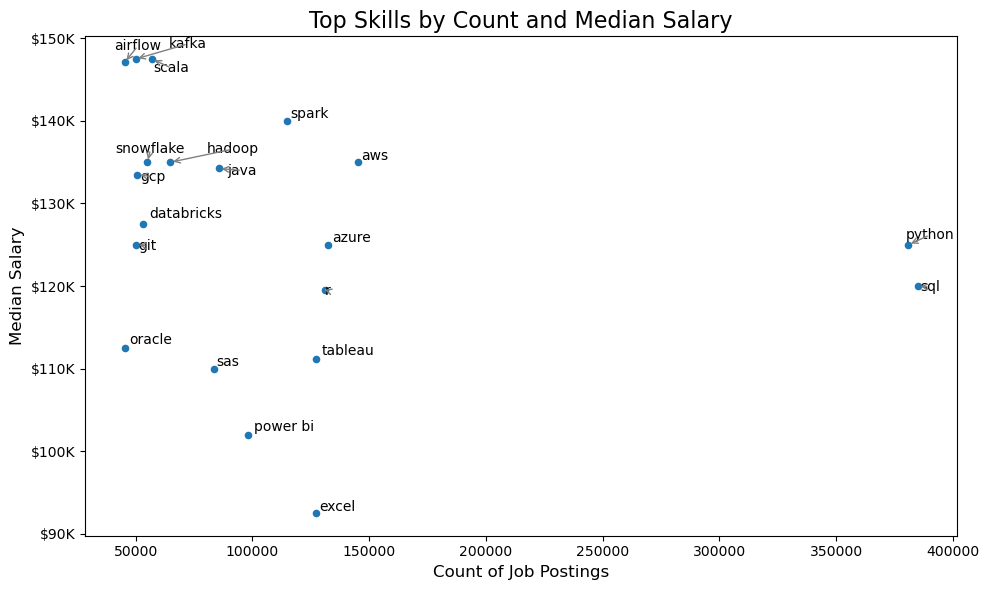

In [29]:
fig, ax = plt.subplots()
skill_stats.plot(kind='scatter',x='skill_count',y='median_salary',ax=ax,figsize=(10,6))
texts = []
for i,txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'][i], skill_stats['median_salary'][i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10)
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${int(x/1000)}K'))

plt.title('Top Skills by Count and Median Salary', fontsize=16)
plt.xlabel('Count of Job Postings', fontsize=12)
plt.ylabel('Median Salary', fontsize=12)
plt.tight_layout()
plt.show()